<a href="https://colab.research.google.com/github/Bellevkey22/Global-CO2-Emissions-Risk-Analysis/blob/main/co2_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np


In [93]:
df = pd.read_csv('/content/visualizing_global_co2_data.csv')
print(df.shape)

(50598, 79)


In [94]:
df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1850,AFG,3752993.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1851,AFG,3767956.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.165,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,Afghanistan,1852,AFG,3783940.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.164,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
3,Afghanistan,1853,AFG,3800954.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.164,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
4,Afghanistan,1854,AFG,3818038.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.163,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [95]:
df.columns.tolist()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'cement_co2',
 'cement_co2_per_capita',
 'co2',
 'co2_growth_abs',
 'co2_growth_prct',
 'co2_including_luc',
 'co2_including_luc_growth_abs',
 'co2_including_luc_growth_prct',
 'co2_including_luc_per_capita',
 'co2_including_luc_per_gdp',
 'co2_including_luc_per_unit_energy',
 'co2_per_capita',
 'co2_per_gdp',
 'co2_per_unit_energy',
 'coal_co2',
 'coal_co2_per_capita',
 'consumption_co2',
 'consumption_co2_per_capita',
 'consumption_co2_per_gdp',
 'cumulative_cement_co2',
 'cumulative_co2',
 'cumulative_co2_including_luc',
 'cumulative_coal_co2',
 'cumulative_flaring_co2',
 'cumulative_gas_co2',
 'cumulative_luc_co2',
 'cumulative_oil_co2',
 'cumulative_other_co2',
 'energy_per_capita',
 'energy_per_gdp',
 'flaring_co2',
 'flaring_co2_per_capita',
 'gas_co2',
 'gas_co2_per_capita',
 'ghg_excluding_lucf_per_capita',
 'ghg_per_capita',
 'land_use_change_co2',
 'land_use_change_co2_per_capita',
 'methane',
 'methane_per_capita',
 

In [96]:
cols_to_keep = [
    'country',
    'year',
    'iso_code',
    'population',
    'gdp',
    'co2',                      # total emissions
    'co2_per_capita',           # emissions per person
    'co2_growth_prct',          # year on year growth rate
    'share_global_co2',         # each country's share of global emissions
    'coal_co2',                 # emissions by fuel source
    'oil_co2',
    'gas_co2',
    'land_use_change_co2',      # deforestation etc
    'energy_per_capita',        # energy consumption
    'co2_per_gdp',              # how carbon efficient is the economy
]

df = df[cols_to_keep]
print(df.shape)

(50598, 15)


In [97]:
df.isnull().sum()

,0
country,0
year,0
iso_code,8456
population,10590
gdp,36034
co2,19249
co2_per_capita,23683
co2_growth_prct,25566
share_global_co2,21242
coal_co2,25529


In [98]:
df[df['iso_code'].isna()]['country'].unique()

array(['Africa', 'Africa (GCP)', 'Asia', 'Asia (GCP)',
       'Asia (excl. China and India)', 'Central America (GCP)', 'Europe',
       'Europe (GCP)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
       'European Union (27)', 'European Union (27) (GCP)',
       'European Union (28)', 'French Equatorial Africa (GCP)',
       'French Equatorial Africa (Jones et al. 2023)',
       'French West Africa (GCP)',
       'French West Africa (Jones et al. 2023)', 'High-income countries',
       'International transport', 'Kosovo', 'Kuwaiti Oil Fires (GCP)',
       'Kuwaiti Oil Fires (Jones et al. 2023)',
       'Least developed countries (Jones et al. 2023)',
       'Leeward Islands (GCP)', 'Leeward Islands (Jones et al. 2023)',
       'Low-income countries', 'Lower-middle-income countries',
       'Middle East (GCP)', 'Non-OECD (GCP)', 'North America',
       'North America (GCP)', 'North America (excl. USA)', 'OECD (GCP)',
       'OECD (Jones et al. 2023)', 'Oceania', 'Oceania (GCP)',
    

In [99]:
# keep only rows from 1990 onwards
df = df[df['year'] >= 1990]
# keep only actual countries (they all have iso_code)
df = df[df['iso_code'].notna()]

print(df.shape)
print(df.isnull().sum())

(7424, 15)
country                   0
year                      0
iso_code                  0
population              129
gdp                    2641
co2                     448
co2_per_capita          466
co2_growth_prct         432
share_global_co2        448
coal_co2                451
oil_co2                 451
gas_co2                 451
land_use_change_co2     640
energy_per_capita       686
co2_per_gdp            2670
dtype: int64


In [100]:
# drop rows with null co2
df = df.dropna(subset=['co2'])
print(df.shape)

(6976, 15)


In [101]:
# reset index
df = df.reset_index(drop=True)
df.head()

,country,year,iso_code,population,gdp,co2,co2_per_capita,co2_growth_prct,share_global_co2,coal_co2,oil_co2,gas_co2,land_use_change_co2,energy_per_capita,co2_per_gdp
0,Afghanistan,1990,AFG,10694804.0,1.306598e+10,2.024,0.189,-26.784,0.009,0.278,1.271,0.403,0.403,2968.316,0.155
1,Afghanistan,1991,AFG,10745168.0,1.204736e+10,1.914,0.178,-5.435,0.008,0.250,1.204,0.389,0.220,1293.862,0.159
2,Afghanistan,1992,AFG,12057436.0,1.267754e+10,1.482,0.123,-22.580,0.007,0.022,1.030,0.363,-1.319,760.342,0.117
3,Afghanistan,1993,AFG,14003764.0,9.834581e+09,1.487,0.106,0.330,0.007,0.018,1.048,0.352,-3.737,650.207,0.151
4,Afghanistan,1994,AFG,15455560.0,7.919857e+09,1.454,0.094,-2.227,0.006,0.015,1.032,0.338,-3.261,570.403,0.184


In [102]:
fuel_cols = ['coal_co2', 'oil_co2', 'gas_co2', 'land_use_change_co2']
df[fuel_cols] = df[fuel_cols].fillna(0)
print(df[fuel_cols].isnull().sum())

coal_co2               0
oil_co2                0
gas_co2                0
land_use_change_co2    0
dtype: int64


In [103]:
df.describe()

,year,population,gdp,co2,co2_per_capita,co2_growth_prct,share_global_co2,coal_co2,oil_co2,gas_co2,land_use_change_co2,energy_per_capita,co2_per_gdp
count,6976.000000,6.958000e+03,4.754000e+03,6976.000000,6958.000000,6960.000000,6976.000000,6976.000000,6976.000000,6976.000000,6976.000000,6564.000000,4754.000000
mean,2005.511755,3.039695e+07,4.493547e+11,132.220809,4.985254,3.563792,0.444836,53.774430,45.380956,25.625587,28.703892,24524.915817,0.348749
std,9.223882,1.228535e+08,1.497983e+12,643.714289,7.758325,25.438650,2.085424,387.920447,185.928263,109.148292,140.923192,33248.943002,0.637075
min,1990.000000,1.833000e+03,2.571720e+08,0.000000,0.000000,-100.000000,0.000000,0.000000,0.000000,0.000000,-92.040000,0.000000,0.000000
25%,1998.000000,6.269378e+05,1.762845e+10,0.791000,0.697250,-2.145250,0.003000,0.000000,0.667000,0.000000,-0.037000,2996.672500,0.151000
50%,2006.000000,5.380420e+06,5.516246e+10,6.406500,2.766000,1.980000,0.021000,0.026000,3.609000,0.007000,0.330000,12719.491500,0.248000
75%,2013.250000,1.927234e+07,2.762720e+11,51.271500,6.911750,7.042250,0.177000,5.847000,22.895000,9.974500,11.652000,32596.404500,0.401000
max,2021.000000,1.425894e+09,1.815162e+13,11472.368000,367.928000,1203.570000,31.069000,7955.985000,2644.237000,1673.999000,2832.235000,317440.500000,37.608000


In [104]:
cleaning_log = {
    'Issue': [
        'Data before1990',
        'Regional aggregates (no iso_code)',
        'Missing co2 values',
        'Missing fuel source values'
    ],
    'Action Taken': [
        'Filtered to year >= 1990',
        'Kept only rows with iso_code',
        'Dropped448 rows',
        'Filled with0'
    ],
    'Rows Affected': [
        43174,
        8456,
        448,
        1804
    ],
    'Reason': [
        'Pre-1990 data too sparse for modern analysis',
        'Regional totals would double-count emissions',
        'co2 is north star metric — unusable without it',
        'Missing fuel data likely reflects zero usage'
    ]
}

log_df = pd.DataFrame(cleaning_log)
log_df

,Issue,Action Taken,Rows Affected,Reason
0,Data before1990,Filtered to year >= 1990,43174,Pre-1990 data too sparse for modern analysis
1,Regional aggregates (no iso_code),Kept only rows with iso_code,8456,Regional totals would double-count emissions
2,Missing co2 values,Dropped448 rows,448,co2 is north star metric — unusable without it
3,Missing fuel source values,Filled with0,1804,Missing fuel data likely reflects zero usage


In [105]:
log_df.to_csv('cleaning_log.csv', index = False)
print("cleaning log saved")

cleaning log saved


In [106]:
global_trend = df.groupby('year')['co2'].sum().reset_index()
print(global_trend)

    year        co2
0   1990  22207.113
1   1991  22699.558
2   1992  22024.087
3   1993  22253.312
4   1994  22382.572
5   1995  22838.637
6   1996  23488.442
7   1997  23596.885
8   1998  23465.130
9   1999  23959.473
10  2000  24670.061
11  2001  24889.215
12  2002  25483.802
13  2003  26819.625
14  2004  27732.324
15  2005  28671.940
16  2006  29598.115
17  2007  30454.388
18  2008  31016.895
19  2009  30539.042
20  2010  32275.197
21  2011  33369.763
22  2012  33903.493
23  2013  34200.145
24  2014  34452.943
25  2015  34391.832
26  2016  34344.556
27  2017  34858.140
28  2018  35547.667
29  2019  35824.500
30  2020  34317.056
31  2021  36096.459


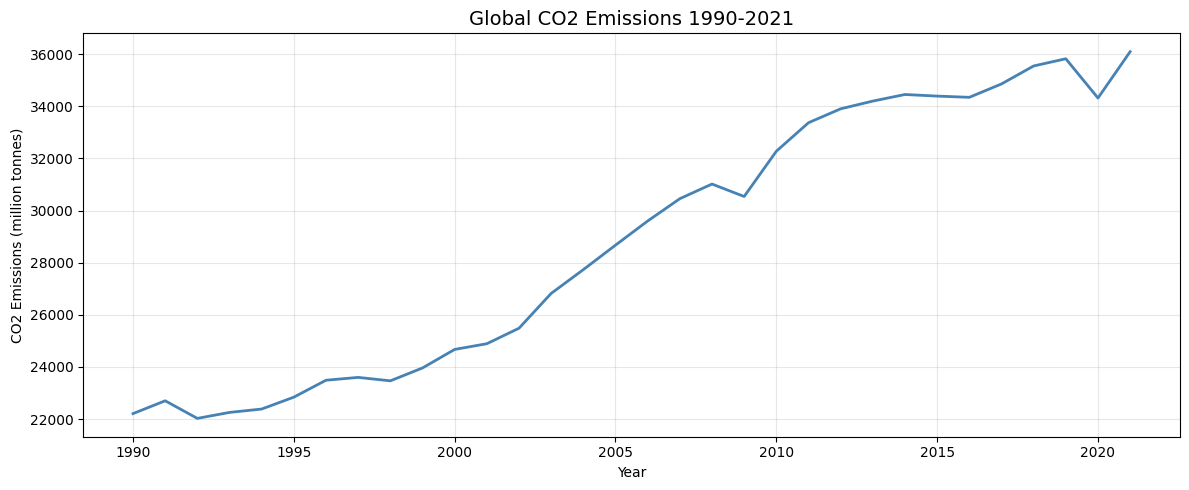

chart saved


<Figure size 640x480 with 0 Axes>

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.plot(global_trend['year'], global_trend['co2'], color = 'steelblue', linewidth = 2)
plt.title('Global CO2 Emissions 1990-2021', fontsize = 14)
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (million tonnes)')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()
plt.savefig('global_trend.png', dpi = 150, bbox_inches = 'tight')
print("chart saved")

# Global CO2 emissions increased by **62%** between 1990 and 2021, rising from 22,207 to 36,096 million tonnes. A significant upward trend driven primarily by industrialisation in emerging economies.





*  2009 — emissions dropped from 31,016 to 30,539. That's the 2008 global financial crisis.

Economic slowdown = less industrial activity = less emissions.
*  2020 — dropped from 35,824 to 34,317. That's COVID-19.

Lockdowns, reduced transport, factories slowing down.
*  2021 — jumped back to 36,096, the highest on record.

Economic rebound after COVID

In [108]:
top10_2021 = df[df['year'] == 2021]\
.groupby('country')['co2']\
.sum()\
.sort_values(ascending = False)\
.head(10)\
.reset_index()
top10_2021

,country,co2
0,China,11472.368
1,United States,5007.336
2,India,2709.684
3,Russia,1755.547
4,Japan,1067.398
5,Iran,748.879
6,Germany,674.754
7,Saudi Arabia,672.380
8,Indonesia,619.278
9,South Korea,616.075


In [110]:
total_2021 = df[df['year'] == 2021]['co2'].sum()
top3_2021 = top10_2021.head(3)['co2'].sum()
share = top3_2021/total_2021 * 100
print(f"Total global emissions 2021: {total_2021:.1f} million tonnes")
print(f"Top 3 countries combined: {top3_2021:.1f} million tonnes")
print(f"Top 3 share of global emissions: {share:.1f}%")

Total global emissions 2021: 36096.5 million tonnes
Top 3 countries combined: 19189.4 million tonnes
Top 3 share of global emissions: 53.2%


China, USA, and India collectively accounted for **53.2%**  of global CO2 emissions in 2021 despite representing a fraction of the world's nations.

This highlights extreme concentration of emissions responsibility.